In [1]:
# Configuration
import os
import sys

os.environ["KERAS_BACKEND"] = "jax"
sys.path.append("..")

In [2]:
# Setup
from importlib import import_module

import numpy as np
from keras import ops
from rich.console import Console
from rich.table import Table

from src.models import (
    GradientBoostedDecisionTree,
    LearnableCutFlowParallel,
    LearnableCutFlowSequential,
    MultiLayerPerceptron,
)
from src.utils import load_model, show_record_dataset, show_record_dataset_correlation

In [3]:
# Parameters
experiment_id = "4.7.2"

# Dataset
dataset_name = "real1"
n_samples = 200000
seed = 42
selected_feature_indices = [0, 2, 4, 5]

# Model
centers = [80, 0.15, 0.025, 2, 2, 0.3]
n_epochs = 200
batch_size = 512

# Figure
bins = 100
feature_names = ["mass", "c2_beta1", "c2_beta2", "d2_beta1", "d2_beta2", "tau21_beta1"]
feature_names_latex = [
    r"$M_{jet}$",
    r"$C_2^{\beta=1}$",
    r"$C_2^{\beta=2}$",
    r"$D_2^{\beta=1}$",
    r"$D_2^{\beta=2}$",
    r"$\tau_{21}^{\beta=1}$",
]

x_train.shape=(76993, 4)
y_train.shape=(76993, 1)
x_test.shape=(76874, 4)
y_test.shape=(76874, 1)


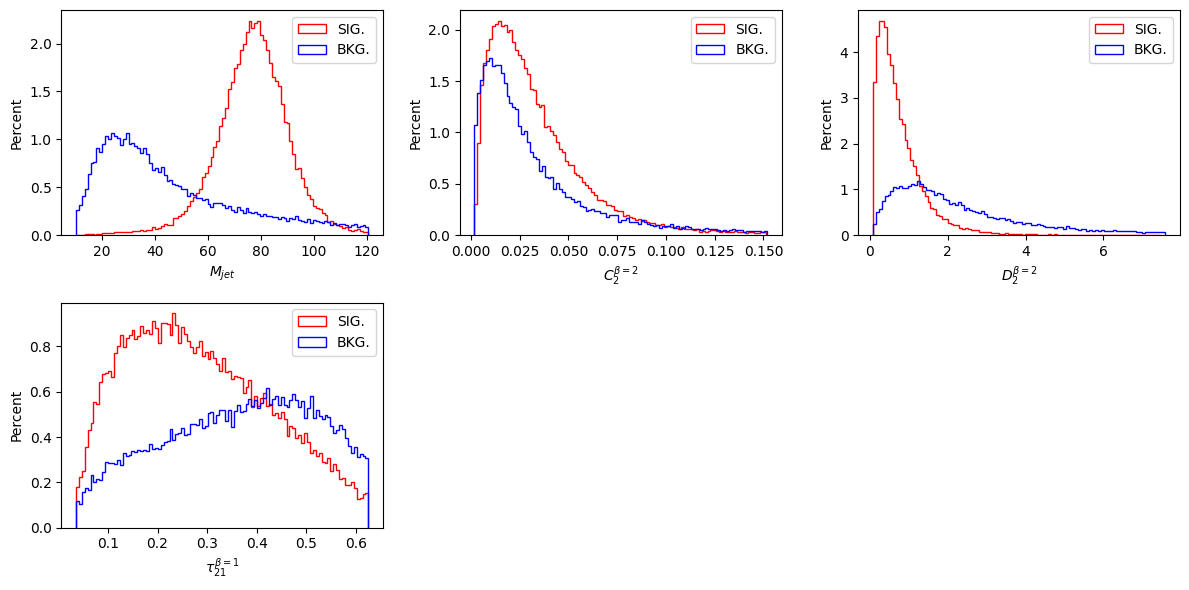

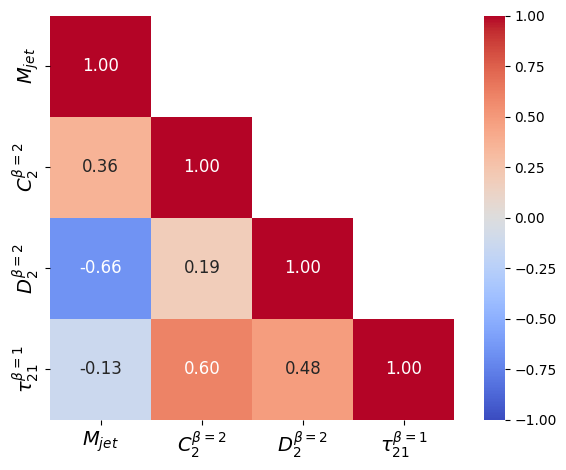

In [4]:
# Dataset
load_data = import_module(f"src.datasets.{dataset_name}").load_data
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

x_train = x_train[:, selected_feature_indices]
x_test = x_test[:, selected_feature_indices]
centers = [centers[i] for i in selected_feature_indices]
feature_names = [feature_names[i] for i in selected_feature_indices]
feature_names_latex = [feature_names_latex[i] for i in selected_feature_indices]

selection = np.ones_like(x_train[:, 0], dtype=bool)
for i in range(x_train.shape[1]):
    p05 = np.percentile(x_train[:, i], 5)
    p95 = np.percentile(x_train[:, i], 95)
    selection = (p05 < x_train[:, i]) & (x_train[:, i] < p95) & selection

x_train = x_train[selection]
y_train = y_train[selection]

selection = np.ones_like(x_test[:, 0], dtype=bool)
for i in range(x_test.shape[1]):
    p05 = np.percentile(x_test[:, i], 5)
    p95 = np.percentile(x_test[:, i], 95)
    selection = (p05 < x_test[:, i]) & (x_test[:, i] < p95) & selection

x_test = x_test[selection]
y_test = y_test[selection]

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

# Figure: feature distribution
show_record_dataset(x_train, y_train, bins, feature_names_latex)

# Figure: feature correlation
show_record_dataset_correlation(x_train, feature_names_latex)

In [5]:
# Model: gradient boosted decision tree
bdt = GradientBoostedDecisionTree(input_shape=x_train.shape, name="bdt")

bdt.compile(optimizer="adam", loss="crossentropy")
bdt.fit(x_train, y_train.squeeze(), epochs=n_epochs, batch_size=batch_size)

bdt.save(f"checkpoints/{experiment_id}-{bdt.name}.pkl")
ckpt_bdt = load_model(f"checkpoints/{experiment_id}-{bdt.name}.pkl")

In [6]:
# Model: multi-layer perceptron
mlp = MultiLayerPerceptron(input_shape=x_train.shape, name="mlp")

mlp.layers[1].adapt(x_train)
mlp.compile(optimizer="adam", loss="crossentropy")
mlp.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

mlp.save(f"checkpoints/{experiment_id}-{mlp.name}.keras")
ckpt_mlp = load_model(f"checkpoints/{experiment_id}-{mlp.name}.keras")

Epoch 1/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 0.5336
Epoch 2/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3392
Epoch 3/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3281
Epoch 4/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3244
Epoch 5/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3283
Epoch 6/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3230
Epoch 7/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3245
Epoch 8/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3222
Epoch 9/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3255
Epoch 10/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3260
Epoch 11/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3217
Epoch 12/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3217
Epoch 13/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3197
Epoch 14/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3226
Epoch 15/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
# Model: learnable cut flow parallel
lcf_par = LearnableCutFlowParallel(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_par",
)

lcf_par.normalization.adapt(x_train)
lcf_par.compile(optimizer="adam", loss="crossentropy")
lcf_par.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_par.save(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")
ckpt_lcf_par = load_model(f"checkpoints/{experiment_id}-{lcf_par.name}.keras")

Epoch 1/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3590
Epoch 2/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3452
Epoch 3/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3354
Epoch 4/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3264
Epoch 5/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3194
Epoch 6/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3139
Epoch 7/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3093
Epoch 8/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 0.3047
Epoch 9/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3005
Epoch 10/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2980
Epoch 11/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2951
Epoch 12/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2930
Epoch 13/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2906  
Epoch 14/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 0.2895
Epoch 15/200
151/151 ━━━━━━━━━━━━━━━

In [8]:
# Model: learnable cut flow sequential
lcf_seq = LearnableCutFlowSequential(
    x_train.shape,
    centers,
    feature_names=feature_names,
    name="lcf_seq",
)

lcf_seq.normalization.adapt(x_train)
lcf_seq.compile(optimizer="adam", loss="crossentropy")
lcf_seq.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size)

lcf_seq.save(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")
ckpt_lcf_seq = load_model(f"checkpoints/{experiment_id}-{lcf_seq.name}.keras")

Epoch 1/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0821
Epoch 2/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0788
Epoch 3/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0809
Epoch 4/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1220
Epoch 5/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1528
Epoch 6/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1655
Epoch 7/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1642
Epoch 8/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1631
Epoch 9/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1640
Epoch 10/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1629
Epoch 11/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1623
Epoch 12/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1622
Epoch 13/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1617
Epoch 14/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1603
Epoch 15/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
# Analysis: metrics
results = []
y_true = y_test

console = Console(force_jupyter=False)
table = Table(title="Model Performance Comparison")
table.add_column("#", justify="center", style="cyan", no_wrap=True)
table.add_column("Model", style="magenta")
table.add_column("TP", justify="right", style="green")
table.add_column("FP", justify="right", style="red")
table.add_column("Accuracy", justify="right", style="blue")
table.add_column("Precision", justify="right", style="blue")
table.add_column("Significance", justify="right", style="yellow")

for i, model in enumerate([bdt, mlp, lcf_par, lcf_seq]):
    y_pred = model.predict(x_test, batch_size=batch_size, verbose=0)
    y_pred = ops.all(y_pred > 0.5, axis=1, keepdims=True)

    tp = ops.sum((y_true == 1) & (y_pred == 1))
    fp = ops.sum((y_true == 0) & (y_pred == 1))
    tn = ops.sum((y_true == 0) & (y_pred == 0))
    fn = ops.sum((y_true == 1) & (y_pred == 0))

    n_preds_true = ops.add(tp, tn)
    n_preds_false = ops.add(fp, fn)
    n_positives = ops.add(tp, fp)
    n_samples = ops.add(n_preds_true, n_preds_false)

    accuracy = ops.divide(n_preds_true, n_samples)
    precision = ops.divide(tp, n_positives)
    significance = ops.divide(tp, ops.sqrt(fp))

    table.add_row(
        str(i + 1),
        model.name,
        f"{tp:.0f}",
        f"{fp:.0f}",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{significance:.4f}",
    )

console.print(table)

                    Model Performance Comparison                    
┏━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ # ┃ Model   ┃    TP ┃   FP ┃ Accuracy ┃ Precision ┃ Significance ┃
┡━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 1 │ bdt     │ 41006 │ 6709 │   0.8657 │    0.8594 │     500.6319 │
│ 2 │ mlp     │ 40814 │ 6383 │   0.8674 │    0.8648 │     510.8540 │
│ 3 │ lcf_par │ 32886 │ 5660 │   0.7737 │    0.8532 │     437.1222 │
│ 4 │ lcf_seq │ 40216 │ 7373 │   0.8468 │    0.8451 │     468.3567 │
└───┴─────────┴───────┴──────┴──────────┴───────────┴──────────────┘
